In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math as m

# To ignore warnings
import warnings 
warnings.filterwarnings("ignore")

In [2]:

# read the dataset
df = pd.read_csv('/kaggle/input/amazon-delivery-dataset/amazon_delivery.csv')

# 1.Initial Exploration of the Data

Goals:
Get a basic understanding of the dataset.

Check the structure and shape (rows × columns).

Preview a few records to see how the data looks.

Identify the types of variables (numeric, categorical, text, datetime).

Detect any obvious missing values or formatting issues.

Build an initial sense of data quality before deeper cleaning or analysis.

In [3]:

# Preview the first 10 rows of the dataset
df.head(10)

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys
5,fxuu788413734,22,4.8,17.431668,78.408321,17.461668,78.438321,2022-03-11,21:20:00,21:30:00,Cloudy,Jam,motorcycle,Urban,130,Toys
6,njmo150975311,33,4.7,23.369746,85.339820,23.479746,85.449820,2022-03-04,19:15:00,19:30:00,Fog,Jam,scooter,Metropolitian,200,Toys
7,jvjc772545076,35,4.6,12.352058,76.606650,12.482058,76.736650,2022-03-14,17:25:00,17:30:00,Cloudy,Medium,motorcycle,Metropolitian,160,Snacks
8,uaeb808891380,22,4.8,17.433809,78.386744,17.563809,78.516744,2022-03-20,20:55:00,21:05:00,Stormy,Jam,motorcycle,Metropolitian,170,Electronics
9,bgvc052754213,36,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55:00,22:10:00,Fog,Jam,motorcycle,Metropolitian,230,Toys


In [4]:
# Display the number of rows and columns
df.shape

(43739, 16)

In [5]:

# Display meta data about each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


In [6]:

# Display summary statistics of numeric columns
df.describe()


,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


In [7]:
# Display summary statistics of categorical columns
df.describe(include='object')



,Order_ID,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Category
count,43739,43739,43739,43739,43648,43739,43739,43739,43739
unique,43739,44,177,193,6,5,4,4,16
top,ialx566343618,2022-03-15,21:55:00,21:30:00,Fog,Low,motorcycle,Metropolitian,Electronics
freq,1,1141,460,481,7440,14999,25527,32698,2849


In [8]:
# Display number of null values in each column
df.isnull().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

# Identifies the unique values in every column

In [9]:
# Display number of unique values of each columns
df.nunique()

Order_ID           43739
Agent_Age             22
Agent_Rating          28
Store_Latitude       521
Store_Longitude      415
Drop_Latitude       4367
Drop_Longitude      4367
Order_Date            44
Order_Time           177
Pickup_Time          193
Weather                6
Traffic                5
Vehicle                4
Area                   4
Delivery_Time         89
Category              16
dtype: int64

In [10]:

# Display unique values of'Agent_Rating' column
df['Agent_Rating'].unique()     #there is nan value 

array([4.9, 4.5, 4.4, 4.7, 4.6, 4.8, 4.2, 4.3, 4. , 4.1, 5. , 3.5, 3.8,
       nan, 3.9, 3.7, 2.6, 2.5, 3.6, 3.1, 2.7, 1. , 3.2, 3.3, 6. , 3.4,
       2.8, 2.9, 3. ])

In [11]:

# Display unique values of 'Weather'column
df['Weather'].unique()       #there is nan value 

array(['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', nan],
      dtype=object)

In [12]:


# Display unique values of 'Traffic'column
df['Traffic'].unique()  #there is nan

array(['High ', 'Jam ', 'Low ', 'Medium ', 'NaN '], dtype=object)

In [13]:
# Display unique values of categorical columns in amazon_delivery dataset
categorical_columns = ['Weather', 'Traffic', 'Vehicle', 'Area', 'Category']

for col in categorical_columns:
    print(f'{col}:')
    print("--------------")
    print(df[col].unique())   
    print("==============")


Weather:
--------------
['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy' nan]
Traffic:
--------------
['High ' 'Jam ' 'Low ' 'Medium ' 'NaN ']
Vehicle:
--------------
['motorcycle ' 'scooter ' 'van' 'bicycle ']
Area:
--------------
['Urban ' 'Metropolitian ' 'Semi-Urban ' 'Other']
Category:
--------------
['Clothing' 'Electronics' 'Sports' 'Cosmetics' 'Toys' 'Snacks' 'Shoes'
 'Apparel' 'Jewelry' 'Outdoors' 'Grocery' 'Books' 'Kitchen' 'Home'
 'Pet Supplies' 'Skincare']


In [14]:
# Display unique values & their counts for each categorical columns
# Display number of unique values of each column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Order_ID: 43739 unique values
Agent_Age: 22 unique values
Agent_Rating: 28 unique values
Store_Latitude: 521 unique values
Store_Longitude: 415 unique values
Drop_Latitude: 4367 unique values
Drop_Longitude: 4367 unique values
Order_Date: 44 unique values
Order_Time: 177 unique values
Pickup_Time: 193 unique values
Weather: 6 unique values
Traffic: 5 unique values
Vehicle: 4 unique values
Area: 4 unique values
Delivery_Time: 89 unique values
Category: 16 unique values


In [15]:
# Display unique values and their frequencies for selected categorical columns
exp_col=['Weather', 'Traffic' , 'Vehicle','Area','Category']

for col in exp_col:
    print(f"Unique values in '{col}':")
    print(df[col].value_counts())

Unique values in 'Weather':
Weather
Fog           7440
Stormy        7374
Cloudy        7288
Sandstorms    7245
Windy         7223
Sunny         7078
Name: count, dtype: int64
Unique values in 'Traffic':
Traffic
Low        14999
Jam        13725
Medium     10628
High        4296
NaN           91
Name: count, dtype: int64
Unique values in 'Vehicle':
Vehicle
motorcycle     25527
scooter        14639
van             3558
bicycle           15
Name: count, dtype: int64
Unique values in 'Area':
Area
Metropolitian     32698
Urban              9751
Other              1138
Semi-Urban          152
Name: count, dtype: int64
Unique values in 'Category':
Category
Electronics     2849
Books           2824
Jewelry         2802
Toys            2781
Skincare        2772
Snacks          2770
Outdoors        2747
Apparel         2726
Sports          2719
Grocery         2691
Pet Supplies    2690
Home            2685
Cosmetics       2677
Kitchen         2673
Clothing        2667
Shoes           2666
Name:

# 2.Data Cleaning¶


Goals:

1.  Drop unnecessary columns & rename for clarity
2. Detect & Remove Duplicate Rows
1. Handle Missing Values
1. Detect & Handle Outliers
1. Detect & Correct Noisy Data
1. Check for Inconsistencies   

# Drop unnecessary columns & rename for clarity# 

In [16]:
# Create a Copy of the Data frame with the name df_clean
df_clean=df.copy()

In [17]:
df_clean

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,Windy,High,motorcycle,Metropolitian,160,Home
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,20:10:00,Windy,Jam,motorcycle,Metropolitian,180,Jewelry
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,Cloudy,Low,scooter,Metropolitian,80,Home
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,Cloudy,High,motorcycle,Metropolitian,130,Kitchen


In [18]:
# Rename ['Agent_Rating'] columns to ['Order_Rating']
df_clean = df_clean.rename(columns=
                          {'Agent_Rating':'Order_Rating'})

In [19]:
df_clean.columns

Index(['Order_ID', 'Agent_Age', 'Order_Rating', 'Store_Latitude',
       'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date',
       'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area',
       'Delivery_Time', 'Category'],
      dtype='object')

# Detect & Remove Duplicate Rows

In [20]:
# Display duplicate rows
df_clean[df_clean.duplicated()]

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category


In [21]:

# Display the number of duplicated rows
df_clean.duplicated().sum() #we haven't duplicates


0

# Handle Missing Values

In [22]:
# Display number of missing values
df_clean.isnull().sum()

Order_ID            0
Agent_Age           0
Order_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [23]:

 #Display summary Stat of'Order_Rating']column
df_clean[['Order_Rating']].describe()

,Order_Rating
count,43685.000000
mean,4.633780
std,0.334716
min,1.000000
25%,4.500000
50%,4.700000
75%,4.900000
max,6.000000


In [24]:

# Display all rows that contain missing values (NaN)
df_clean[df_clean.isnull().any(axis=1)]

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
124,uurs547552548,23,NaN,22.569358,88.433452,22.599358,88.463452,2022-02-17,23:25:00,23:35:00,Sunny,Low,motorcycle,Metropolitian,75,Snacks
1996,xoaj834389107,32,NaN,0.000000,0.000000,0.050000,0.050000,2022-02-11,20:50:00,21:00:00,Sandstorms,Jam,motorcycle,Urban,185,Snacks
2002,lasr795083832,23,NaN,25.454648,81.834502,25.584648,81.964502,2022-02-18,19:50:00,19:55:00,Windy,Jam,motorcycle,Metropolitian,150,Outdoors
2018,gjcr517387117,26,NaN,0.000000,0.000000,0.080000,0.080000,2022-02-16,23:50:00,23:55:00,Cloudy,Low,scooter,Metropolitian,140,Clothing
2286,xige084493792,15,1.0,-26.891191,75.802083,26.981191,75.892083,2022-03-12,NaN,17:20:00,NaN,NaN,motorcycle,Urban,75,Home
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41504,ogxf318978500,20,NaN,25.451517,81.832616,25.501517,81.882616,2022-02-13,22:15:00,22:30:00,Stormy,Low,scooter,Urban,85,Shoes
42598,llox673359294,15,1.0,0.000000,0.000000,0.070000,0.070000,2022-03-14,NaN,17:40:00,NaN,NaN,scooter,Metropolitian,170,Jewelry
43027,qhka163034669,20,NaN,22.514585,88.393310,22.594585,88.473310,2022-02-14,22:20:00,22:25:00,Fog,Low,scooter,Metropolitian,100,Electronics
43053,ifig993965994,15,1.0,13.086438,80.220672,13.216439,80.350672,2022-03-18,NaN,18:00:00,NaN,NaN,van,Urban,130,Jewelry


# Fill missing values

In [25]:
# Display the median of ['Order_Rating']
df_clean['Order_Rating'].median()

4.7

In [26]:

# Fill missing values in: ['Order_Rating']with the median 
df_clean['Order_Rating']= df_clean['Order_Rating'].fillna(df_clean['Order_Rating'].median())

In [27]:
df_clean['Order_Rating'].isnull().sum()

0

In [28]:
# Display mode of ['Weather']
df_clean['Weather'].mode()

0    Fog
Name: Weather, dtype: object

In [29]:
# Fill missing values in: ['Weather']with the mode of Options ' Fog'
df_clean['Weather']= df_clean['Weather'].fillna(df_clean['Weather'].mode()[0])

In [30]:
df_clean['Weather'].isnull().sum()

0

In [31]:
df_clean['Traffic'].isnull().sum()

0

In [32]:
# Display unique values of 'Traffic'column
df_clean['Traffic'].unique()

array(['High ', 'Jam ', 'Low ', 'Medium ', 'NaN '], dtype=object)

In [33]:
# Filter rows in df where the Traffic column in df_clean contains the string 'NaN'
df[df_clean['Traffic']=='NaN ']

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
2286,xige084493792,15,1.0,-26.891191,75.802083,26.981191,75.892083,2022-03-12,NaN,17:20:00,NaN,NaN,motorcycle,Urban,75,Home
2779,oilg311747812,15,1.0,22.750040,75.902847,22.810040,75.962847,2022-04-03,NaN,20:30:00,NaN,NaN,scooter,Metropolitian,145,Kitchen
2825,pbox816153129,15,1.0,21.149569,72.772697,21.209569,72.832697,2022-03-21,NaN,22:10:00,NaN,NaN,bicycle,Metropolitian,100,Clothing
3438,nzsa056960624,50,6.0,-12.970324,-77.645748,13.010324,77.685748,2022-03-13,NaN,12:30:00,NaN,NaN,van,Urban,125,Cosmetics
4514,eids248121351,50,6.0,-17.451976,-78.385883,17.561976,78.495883,2022-04-04,NaN,23:20:00,NaN,NaN,bicycle,Metropolitian,135,Jewelry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40359,lasg907081524,50,6.0,22.751234,75.889490,22.781234,75.919490,2022-03-17,NaN,20:40:00,NaN,NaN,scooter,Metropolitian,140,Apparel
41088,wgdm794380305,50,6.0,-12.939496,77.625999,12.949496,77.635999,2022-03-19,NaN,09:40:00,NaN,NaN,van,Metropolitian,95,Books
42598,llox673359294,15,1.0,0.000000,0.000000,0.070000,0.070000,2022-03-14,NaN,17:40:00,NaN,NaN,scooter,Metropolitian,170,Jewelry
43053,ifig993965994,15,1.0,13.086438,80.220672,13.216439,80.350672,2022-03-18,NaN,18:00:00,NaN,NaN,van,Urban,130,Jewelry


In [34]:
# Replace the string 'NaN ' in the Traffic column with actual NaN values
df_clean["Traffic"] = df_clean["Traffic"].replace('NaN ', np.nan)

In [35]:
df_clean["Traffic"].isnull().sum()

91

In [36]:
# Display the mode of["Traffic"]
df_clean['Traffic'].mode()

0    Low 
Name: Traffic, dtype: object

In [37]:

# Fill missing values in: ['Traffic']with the mode of 'Traffic' low
df_clean['Traffic'].fillna(df_clean['Traffic'].mode()[0],inplace=True)

In [38]:
df_clean['Traffic']

0          High 
1           Jam 
2           Low 
3        Medium 
4          High 
          ...   
43734      High 
43735       Jam 
43736       Low 
43737      High 
43738    Medium 
Name: Traffic, Length: 43739, dtype: object

In [39]:
df_clean['Traffic'].isnull().sum()

0

In [40]:
df_clean['Traffic'].unique()

array(['High ', 'Jam ', 'Low ', 'Medium '], dtype=object)

In [41]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Order_Rating     43739 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43739 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


In [42]:
df_clean

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,Windy,High,motorcycle,Metropolitian,160,Home
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,20:10:00,Windy,Jam,motorcycle,Metropolitian,180,Jewelry
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,Cloudy,Low,scooter,Metropolitian,80,Home
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,Cloudy,High,motorcycle,Metropolitian,130,Kitchen


In [43]:
# Check again for null values
df_clean.isnull().sum()

Order_ID           0
Agent_Age          0
Order_Rating       0
Store_Latitude     0
Store_Longitude    0
Drop_Latitude      0
Drop_Longitude     0
Order_Date         0
Order_Time         0
Pickup_Time        0
Weather            0
Traffic            0
Vehicle            0
Area               0
Delivery_Time      0
Category           0
dtype: int64

# Detect & Handle Outliers

In [44]:
# Display data types of each column
df_clean.dtypes.to_frame("Data_Type")

,Data_Type
Order_ID,object
Agent_Age,int64
Order_Rating,float64
Store_Latitude,float64
Store_Longitude,float64
Drop_Latitude,float64
Drop_Longitude,float64
Order_Date,object
Order_Time,object
Pickup_Time,object


In [45]:
# Display summary Stat of numerical columns
df_clean.describe()

,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633862,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334518,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


<Axes: xlabel='Agent_Age', ylabel='Density'>

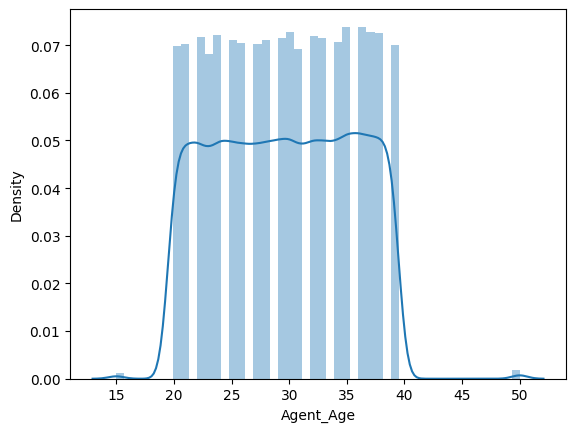

In [46]:
# Detect outliers in ['Agent_Age'] column: Using Distribution Plot
sns.distplot(df_clean['Agent_Age'])

<Axes: xlabel='Agent_Age'>

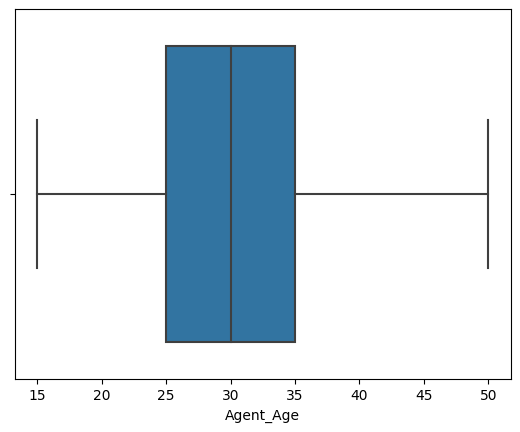

In [47]:
# Detect outliers in ['Agent_Age'] column: Using Box Plot
sns.boxplot(x=df_clean['Agent_Age'])

In [48]:
# Detect outliers in ['Agent_Age'] column: Using IQR Method
Q1 = df_clean['Agent_Age'].quantile(0.25)
print(Q1)

Q3 = df_clean['Agent_Age'].quantile(0.75)
print(Q3)

IQR = Q3 - Q1
print(IQR)

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

print(upper)
print(lower)

25.0
35.0
10.0
50.0
10.0


<Axes: xlabel='Order_Rating', ylabel='Density'>

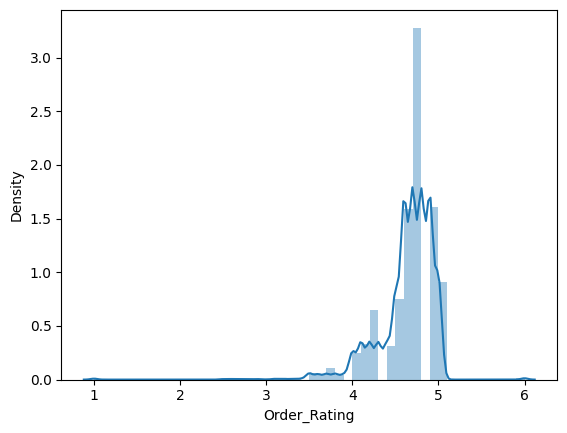

In [49]:
# Detect outliers in ['Order_Rating'] column: Using Distribution Plot
sns.distplot(df_clean['Order_Rating'])

In [50]:
# Detect outliers in ['Order_Rating'] column: Using IQR Method
Q1 = df_clean['Order_Rating'].quantile(0.25)
print(Q1)

Q3 = df_clean['Order_Rating'].quantile(0.75)
print(Q3)

IQR = Q3 - Q1
print(IQR)

upper =5
lower =1

print(upper)
print(lower)

4.5
4.9
0.40000000000000036
5
1


In [51]:
# Remove outliers
df_clean = df_clean[(df_clean['Order_Rating'] >= lower) & (df_clean['Order_Rating'] <= upper)]

# Check for Inconsistencies

# Detect & Correct Noisy Data

In [52]:
# Filter rows where Order_Rating is greater than 5 (invalid ratings above the maximum allowed 5)
df_clean[df_clean['Order_Rating'] >5]  # no rating more than 6

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category


In [53]:
# Check if 'Order_Time' column contains invalid or noisy values (like NaN, null, blanks, or NaT) 
df_clean['Order_Time'][df_clean['Order_Time'].str.strip().str.upper()=='NAN']


2286     NaN 
2779     NaN 
2825     NaN 
5659     NaN 
8783     NaN 
10466    NaN 
10687    NaN 
11610    NaN 
14530    NaN 
15307    NaN 
15458    NaN 
15826    NaN 
20410    NaN 
21446    NaN 
22160    NaN 
22589    NaN 
22736    NaN 
22754    NaN 
24877    NaN 
25595    NaN 
25863    NaN 
26051    NaN 
26832    NaN 
26891    NaN 
28476    NaN 
29962    NaN 
30673    NaN 
31861    NaN 
33545    NaN 
34557    NaN 
35599    NaN 
36155    NaN 
37491    NaN 
37498    NaN 
38653    NaN 
39569    NaN 
42598    NaN 
43053    NaN 
Name: Order_Time, dtype: object

In [54]:
# Replace invalid placeholders in 'Order_Time' column with proper NaN values
df_clean['Order_Time'][df_clean['Order_Time'].str.strip().str.upper()=='NAN']=np.nan


In [55]:
df_clean[pd.isna(df_clean['Order_Time'])]

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
2286,xige084493792,15,1.0,-26.891191,75.802083,26.981191,75.892083,2022-03-12,NaN,17:20:00,Fog,Low,motorcycle,Urban,75,Home
2779,oilg311747812,15,1.0,22.750040,75.902847,22.810040,75.962847,2022-04-03,NaN,20:30:00,Fog,Low,scooter,Metropolitian,145,Kitchen
2825,pbox816153129,15,1.0,21.149569,72.772697,21.209569,72.832697,2022-03-21,NaN,22:10:00,Fog,Low,bicycle,Metropolitian,100,Clothing
5659,pjec796867569,15,1.0,13.026286,80.275235,13.056286,80.305235,2022-03-11,NaN,20:50:00,Fog,Low,bicycle,Metropolitian,125,Electronics
8783,ebhx017527500,15,1.0,12.970324,77.645748,13.080324,77.755748,2022-03-25,NaN,23:25:00,Fog,Low,motorcycle,Metropolitian,170,Snacks
10466,loqy430001953,15,1.0,19.181300,72.836191,19.231300,72.886191,2022-03-30,NaN,20:55:00,Fog,Low,motorcycle,Metropolitian,195,Clothing
10687,wxzn327559387,15,1.0,-21.183434,-72.814492,21.193434,72.824492,2022-03-05,NaN,11:30:00,Fog,Low,scooter,Urban,135,Jewelry
11610,dlmc121704817,15,1.0,22.751857,75.866699,22.801857,75.916699,2022-03-24,NaN,21:15:00,Fog,Low,bicycle,Metropolitian,140,Skincare
14530,vnkn657645307,15,1.0,0.000000,0.000000,0.070000,0.070000,2022-03-16,NaN,23:55:00,Fog,Low,bicycle,Metropolitian,105,Sports
15307,jbvk101196693,15,1.0,13.022394,80.242439,13.072394,80.292439,2022-03-11,NaN,18:10:00,Fog,Low,bicycle,Metropolitian,85,Books


In [56]:
# Drop rows with missing values in 'Order_Time' column and check remaining nulls
df_clean = df_clean.dropna(subset=['Order_Time'])

print(df_clean['Order_Time'].isnull().sum())

0


In [57]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43648 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43648 non-null  object 
 1   Agent_Age        43648 non-null  int64  
 2   Order_Rating     43648 non-null  float64
 3   Store_Latitude   43648 non-null  float64
 4   Store_Longitude  43648 non-null  float64
 5   Drop_Latitude    43648 non-null  float64
 6   Drop_Longitude   43648 non-null  float64
 7   Order_Date       43648 non-null  object 
 8   Order_Time       43648 non-null  object 
 9   Pickup_Time      43648 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43648 non-null  object 
 12  Vehicle          43648 non-null  object 
 13  Area             43648 non-null  object 
 14  Delivery_Time    43648 non-null  int64  
 15  Category         43648 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.7+ MB


In [58]:
df_clean["Area"].unique()

array(['Urban ', 'Metropolitian ', 'Semi-Urban ', 'Other'], dtype=object)

In [59]:
df_clean["Traffic"].unique()

array(['High ', 'Jam ', 'Low ', 'Medium '], dtype=object)

In [60]:
# Select rows where Drop_Latitude is invalid:
# Less than -90, greater than 90, or equal to 0
df_clean[
    (df_clean["Drop_Latitude"] < -90) | 
    (df_clean["Drop_Latitude"] > 90) |
    ((df_clean["Drop_Longitude"] == 0) & (df_clean["Drop_Latitude"] == 0))  ] 

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category


In [61]:
# Select rows where Store_Latitude is invalid:
# Less than -90, greater than 90, or equal to 0
df_clean[
    (df_clean["Store_Latitude"] < -90) | 
    (df_clean["Store_Latitude"] > 90) ]

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category


In [62]:
# Select rows where Store_Longitude is invalid:
# Less than -180, greater than 180, or equal to 0
df_clean[
    (df_clean["Store_Longitude"] < -180) | 
    (df_clean["Store_Longitude"] > 180) ]

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category


In [63]:
# Select rows where Drop_Longitude is invalid:
# Less than -180, greater than 180, or equal to 0
df_clean[
    (df_clean["Drop_Longitude"] < -180) | 
    (df_clean["Drop_Longitude"] > 180) ]

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category


# Data preprocessing 

<Axes: xlabel='Delivery_Time', ylabel='Density'>

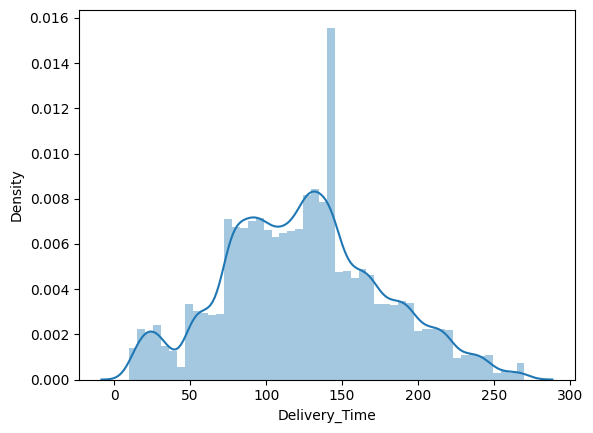

In [64]:
sns.distplot(df_clean['Delivery_Time'])

In [65]:
# Calculate the great-circle distance between two points on Earth
# using the Haversine formula.
# Inputs: lat1, lon1, lat2, lon2 in degrees
# Output: distance in kilometers
def haversine(lat1, lon1, lat2, lon2):
    R = 6378  

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


In [66]:
# Calculate the distance (in kilometers) between the store and drop-off points
# for each order using the haversine function and store it in a new column 'Distance_km'
df_clean['Distance_km'] = haversine(
    df_clean['Store_Latitude'],
    df_clean['Store_Longitude'],
    df_clean['Drop_Latitude'],
    df_clean['Drop_Longitude']
)
# Get summary statistics (count, mean, std, min, max, quartiles) of the distances
df_clean['Distance_km'].describe()

count    43648.000000
mean        27.285378
std        304.149577
min          1.466677
25%          4.668556
50%          9.230549
75%         13.697198
max       6892.290845
Name: Distance_km, dtype: float64

<Axes: xlabel='Distance_km'>

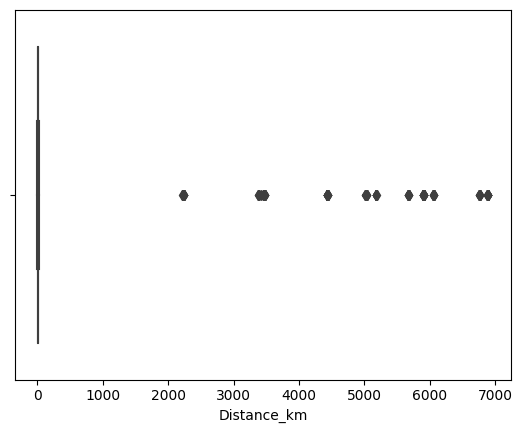

In [67]:
sns.boxplot(x=df_clean['Distance_km'])

In [68]:
# Calculate the Interquartile Range (IQR) to detect outliers in 'Distance_km
Q1 = df_clean['Distance_km'].quantile(0.25)
Q3 = df_clean['Distance_km'].quantile(0.75)


IQR = Q3 - Q1


lower_bound =0
upper_bound =100
print(lower_bound)
print(upper_bound)
print(Q1)
print(Q3)
print(IQR)


0
100
4.668556048020116
13.697197575006479
9.028641526986362


In [69]:
# Filter rows where Distance_km is an outlier
df_clean = df_clean[(df_clean['Distance_km'] >= lower_bound) & (df_clean['Distance_km'] <= upper_bound)]

<Axes: xlabel='Distance_km'>

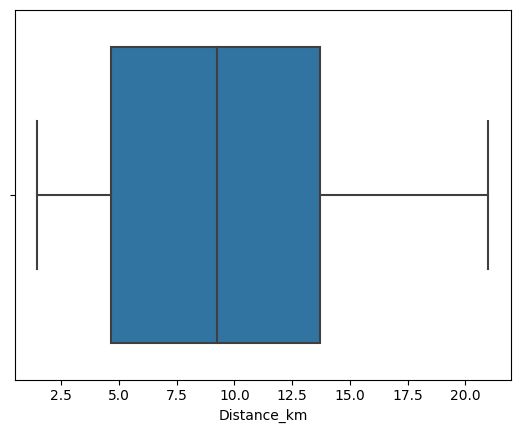

In [70]:
sns.boxplot(x=df_clean['Distance_km'])

In [71]:
df_clean

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Distance_km
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,3.028473
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,20.205706
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,1.554464
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,7.798961
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,6.216961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,Windy,High,motorcycle,Metropolitian,160,Home,1.491483
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,20:10:00,Windy,Jam,motorcycle,Metropolitian,180,Jewelry,11.019829
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,Cloudy,Low,scooter,Metropolitian,80,Home,4.662312
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,Cloudy,High,motorcycle,Metropolitian,130,Kitchen,6.239241


In [72]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43492 entries, 0 to 43738
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43492 non-null  object 
 1   Agent_Age        43492 non-null  int64  
 2   Order_Rating     43492 non-null  float64
 3   Store_Latitude   43492 non-null  float64
 4   Store_Longitude  43492 non-null  float64
 5   Drop_Latitude    43492 non-null  float64
 6   Drop_Longitude   43492 non-null  float64
 7   Order_Date       43492 non-null  object 
 8   Order_Time       43492 non-null  object 
 9   Pickup_Time      43492 non-null  object 
 10  Weather          43492 non-null  object 
 11  Traffic          43492 non-null  object 
 12  Vehicle          43492 non-null  object 
 13  Area             43492 non-null  object 
 14  Delivery_Time    43492 non-null  int64  
 15  Category         43492 non-null  object 
 16  Distance_km      43492 non-null  float64
dtypes: float64(6), in

In [73]:
# Create a mapping for weather classification
weather_mapping = {
    "Sunny": "Good_Weather",
    "Cloudy": "Bad_Weather",
    "Windy": "Bad_Weather",
    "Fog": "Bad_Weather",
    "Stormy": "Extra_Bad_Weather",
    "Sandstorms": "Extra_Bad_Weather"
}

# Apply mapping to create new column
df_clean["Weather_Category"] = df_clean["Weather"].map(weather_mapping)

# Preview
print(df_clean[["Weather", "Weather_Category"]].head(15))

       Weather   Weather_Category
0        Sunny       Good_Weather
1       Stormy  Extra_Bad_Weather
2   Sandstorms  Extra_Bad_Weather
3        Sunny       Good_Weather
4       Cloudy        Bad_Weather
5       Cloudy        Bad_Weather
6          Fog        Bad_Weather
7       Cloudy        Bad_Weather
8       Stormy  Extra_Bad_Weather
9          Fog        Bad_Weather
10      Stormy  Extra_Bad_Weather
11  Sandstorms  Extra_Bad_Weather
12  Sandstorms  Extra_Bad_Weather
13         Fog        Bad_Weather
14  Sandstorms  Extra_Bad_Weather


In [74]:
df_clean['Weather_Category'].unique()

array(['Good_Weather', 'Extra_Bad_Weather', 'Bad_Weather'], dtype=object)

In [75]:
df_clean.head()

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Distance_km,Weather_Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,3.028473,Good_Weather
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,20.205706,Extra_Bad_Weather
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,1.554464,Extra_Bad_Weather
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,7.798961,Good_Weather
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,6.216961,Bad_Weather


In [76]:
# Calculate delivery speed in km/h using distance (km) and delivery time (minutes)
df_clean['Speed_kmph'] = df_clean['Distance_km'] / (df_clean['Delivery_Time'] / 60)

In [77]:
df_clean['Speed_kmph'].describe()

count    43492.000000
mean         5.935174
std          6.683337
min          0.339575
25%          2.637354
50%          4.326829
75%          6.813108
max        119.982599
Name: Speed_kmph, dtype: float64

In [78]:
df_clean=df_clean[df_clean['Speed_kmph']<100] 

In [79]:

# Categorize delivery speed (Speed_kmph) into labeled ranges (e.g., Fast, Medium, Slow)
bins=[0,10,20,50,100 ]

labels=[ 'Slow','Medium','Fast','Very fast']


df_clean['Speed_delivery']=pd.cut(df_clean['Speed_kmph'], bins=bins , labels=labels)

df_clean

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Distance_km,Weather_Category,Speed_kmph,Speed_delivery
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,3.028473,Good_Weather,1.514237,Slow
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,20.205706,Extra_Bad_Weather,7.347529,Slow
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,1.554464,Extra_Bad_Weather,0.717445,Slow
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,7.798961,Good_Weather,4.456549,Slow
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,6.216961,Bad_Weather,2.486784,Slow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,Windy,High,motorcycle,Metropolitian,160,Home,1.491483,Bad_Weather,0.559306,Slow
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,20:10:00,Windy,Jam,motorcycle,Metropolitian,180,Jewelry,11.019829,Bad_Weather,3.673276,Slow
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,Cloudy,Low,scooter,Metropolitian,80,Home,4.662312,Bad_Weather,3.496734,Slow
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,Cloudy,High,motorcycle,Metropolitian,130,Kitchen,6.239241,Bad_Weather,2.879650,Slow


In [80]:
# Combine 'Order_Date' and 'Order_Time' into a single datetime column
# Both must be strings (object) or already datetime-like
df_clean['Order_DateTime'] = pd.to_datetime(df_clean['Order_Date'].astype(str) + " " + df_clean['Order_Time'].astype(str))

# Preview the new column
df_clean[['Order_Date', 'Order_Time', 'Order_DateTime']].head()


,Order_Date,Order_Time,Order_DateTime
0,2022-03-19,11:30:00,2022-03-19 11:30:00
1,2022-03-25,19:45:00,2022-03-25 19:45:00
2,2022-03-19,08:30:00,2022-03-19 08:30:00
3,2022-04-05,18:00:00,2022-04-05 18:00:00
4,2022-03-26,13:30:00,2022-03-26 13:30:00


In [81]:
# Combine 'Order_Date' and 'Pickup_Time' into a single datetime column
df_clean['Pickup_DateTime'] = pd.to_datetime(
    df_clean['Order_Date'].astype(str) + " " + df_clean['Pickup_Time'].astype(str),
    errors='coerce'
)

# Preview
df_clean[['Order_Date', 'Pickup_Time', 'Pickup_DateTime']].head()


,Order_Date,Pickup_Time,Pickup_DateTime
0,2022-03-19,11:45:00,2022-03-19 11:45:00
1,2022-03-25,19:50:00,2022-03-25 19:50:00
2,2022-03-19,08:45:00,2022-03-19 08:45:00
3,2022-04-05,18:10:00,2022-04-05 18:10:00
4,2022-03-26,13:45:00,2022-03-26 13:45:00


In [82]:
# Convert 'Order_Time' column from string (object) to datetime format
# 'errors=coerce' will replace invalid values with NaT (Not a Time)
df_clean['Order_Time'] = pd.to_datetime(df_clean['Order_Time'], errors='coerce')

# Extract the hour (0–23) from the 'Order_Time' column
df_clean['Hours'] = df_clean['Order_Time'].dt.hour

# Preview the first rows of 'Order_Time' and the new 'Hours' column
df_clean[['Order_Time', 'Hours']].head()


,Order_Time,Hours
0,2025-08-22 11:30:00,11
1,2025-08-22 19:45:00,19
2,2025-08-22 08:30:00,8
3,2025-08-22 18:00:00,18
4,2025-08-22 13:30:00,13


In [83]:
df_clean

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,...,Area,Delivery_Time,Category,Distance_km,Weather_Category,Speed_kmph,Speed_delivery,Order_DateTime,Pickup_DateTime,Hours
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2025-08-22 11:30:00,11:45:00,...,Urban,120,Clothing,3.028473,Good_Weather,1.514237,Slow,2022-03-19 11:30:00,2022-03-19 11:45:00,11
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2025-08-22 19:45:00,19:50:00,...,Metropolitian,165,Electronics,20.205706,Extra_Bad_Weather,7.347529,Slow,2022-03-25 19:45:00,2022-03-25 19:50:00,19
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2025-08-22 08:30:00,08:45:00,...,Urban,130,Sports,1.554464,Extra_Bad_Weather,0.717445,Slow,2022-03-19 08:30:00,2022-03-19 08:45:00,8
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2025-08-22 18:00:00,18:10:00,...,Metropolitian,105,Cosmetics,7.798961,Good_Weather,4.456549,Slow,2022-04-05 18:00:00,2022-04-05 18:10:00,18
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2025-08-22 13:30:00,13:45:00,...,Metropolitian,150,Toys,6.216961,Bad_Weather,2.486784,Slow,2022-03-26 13:30:00,2022-03-26 13:45:00,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,2025-08-22 11:35:00,11:45:00,...,Metropolitian,160,Home,1.491483,Bad_Weather,0.559306,Slow,2022-03-24 11:35:00,2022-03-24 11:45:00,11
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,2025-08-22 19:55:00,20:10:00,...,Metropolitian,180,Jewelry,11.019829,Bad_Weather,3.673276,Slow,2022-02-16 19:55:00,2022-02-16 20:10:00,19
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,2025-08-22 23:50:00,00:05:00,...,Metropolitian,80,Home,4.662312,Bad_Weather,3.496734,Slow,2022-03-11 23:50:00,2022-03-11 00:05:00,23
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,2025-08-22 13:35:00,13:40:00,...,Metropolitian,130,Kitchen,6.239241,Bad_Weather,2.879650,Slow,2022-03-07 13:35:00,2022-03-07 13:40:00,13


In [84]:
# Define bins and labels for time categories
bins = [0, 6, 12, 18, 24]  
labels = ['Night', 'Morning', 'Afternoon', 'Evening']

# Create a new column for time category
df_clean['Order_Time_Category'] = pd.cut(df_clean['Hours'], bins=bins, labels=labels, right=False, include_lowest=True)

# Preview
df_clean[['Order_Time', 'Hours', 'Order_Time_Category']].head()

,Order_Time,Hours,Order_Time_Category
0,2025-08-22 11:30:00,11,Morning
1,2025-08-22 19:45:00,19,Evening
2,2025-08-22 08:30:00,8,Morning
3,2025-08-22 18:00:00,18,Evening
4,2025-08-22 13:30:00,13,Afternoon


In [85]:
df_clean.head()

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,...,Delivery_Time,Category,Distance_km,Weather_Category,Speed_kmph,Speed_delivery,Order_DateTime,Pickup_DateTime,Hours,Order_Time_Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2025-08-22 11:30:00,11:45:00,...,120,Clothing,3.028473,Good_Weather,1.514237,Slow,2022-03-19 11:30:00,2022-03-19 11:45:00,11,Morning
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2025-08-22 19:45:00,19:50:00,...,165,Electronics,20.205706,Extra_Bad_Weather,7.347529,Slow,2022-03-25 19:45:00,2022-03-25 19:50:00,19,Evening
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2025-08-22 08:30:00,08:45:00,...,130,Sports,1.554464,Extra_Bad_Weather,0.717445,Slow,2022-03-19 08:30:00,2022-03-19 08:45:00,8,Morning
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2025-08-22 18:00:00,18:10:00,...,105,Cosmetics,7.798961,Good_Weather,4.456549,Slow,2022-04-05 18:00:00,2022-04-05 18:10:00,18,Evening
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2025-08-22 13:30:00,13:45:00,...,150,Toys,6.216961,Bad_Weather,2.486784,Slow,2022-03-26 13:30:00,2022-03-26 13:45:00,13,Afternoon


In [86]:
# Remove extra spaces and convert to consistent case
df_clean["Area_clean"] = df_clean["Area"].str.strip().str.title()

# Correct mapping without spaces
area_mapping = {
    "Urban": "Urban",
    "Semi-Urban": "Urban",
    "Metropolitian": "Metropolitan",  # keep typo if dataset uses it
    "Other": "Other"
}

# Apply mapping and fill unknown values as 'Other'
df_clean["Area_Category"] = df_clean["Area_clean"].map(area_mapping).fillna("Other")

# Preview
print(df_clean[["Area", "Area_clean", "Area_Category"]].head())


             Area     Area_clean Area_Category
0          Urban           Urban         Urban
1  Metropolitian   Metropolitian  Metropolitan
2          Urban           Urban         Urban
3  Metropolitian   Metropolitian  Metropolitan
4  Metropolitian   Metropolitian  Metropolitan


In [105]:
bins=[20,25,30,35,39]
labels =  ['20-25', '25-30', '30-35', '35-40']

df_clean ['Age_segment']=pd.cut(df_clean['Agent_Age'] , bins=bins , labels=labels , right=False)

df_clean ['Age_segment']

0        35-40
1        30-35
2        20-25
3        35-40
4        30-35
         ...  
43734    30-35
43735    20-25
43736    30-35
43737    20-25
43738    20-25
Name: Age_segment, Length: 43487, dtype: category
Categories (4, object): ['20-25' < '25-30' < '30-35' < '35-40']

In [87]:
df_clean

,Order_ID,Agent_Age,Order_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,...,Distance_km,Weather_Category,Speed_kmph,Speed_delivery,Order_DateTime,Pickup_DateTime,Hours,Order_Time_Category,Area_clean,Area_Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2025-08-22 11:30:00,11:45:00,...,3.028473,Good_Weather,1.514237,Slow,2022-03-19 11:30:00,2022-03-19 11:45:00,11,Morning,Urban,Urban
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2025-08-22 19:45:00,19:50:00,...,20.205706,Extra_Bad_Weather,7.347529,Slow,2022-03-25 19:45:00,2022-03-25 19:50:00,19,Evening,Metropolitian,Metropolitan
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2025-08-22 08:30:00,08:45:00,...,1.554464,Extra_Bad_Weather,0.717445,Slow,2022-03-19 08:30:00,2022-03-19 08:45:00,8,Morning,Urban,Urban
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2025-08-22 18:00:00,18:10:00,...,7.798961,Good_Weather,4.456549,Slow,2022-04-05 18:00:00,2022-04-05 18:10:00,18,Evening,Metropolitian,Metropolitan
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2025-08-22 13:30:00,13:45:00,...,6.216961,Bad_Weather,2.486784,Slow,2022-03-26 13:30:00,2022-03-26 13:45:00,13,Afternoon,Metropolitian,Metropolitan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,2025-08-22 11:35:00,11:45:00,...,1.491483,Bad_Weather,0.559306,Slow,2022-03-24 11:35:00,2022-03-24 11:45:00,11,Morning,Metropolitian,Metropolitan
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,2025-08-22 19:55:00,20:10:00,...,11.019829,Bad_Weather,3.673276,Slow,2022-02-16 19:55:00,2022-02-16 20:10:00,19,Evening,Metropolitian,Metropolitan
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,2025-08-22 23:50:00,00:05:00,...,4.662312,Bad_Weather,3.496734,Slow,2022-03-11 23:50:00,2022-03-11 00:05:00,23,Evening,Metropolitian,Metropolitan
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,2025-08-22 13:35:00,13:40:00,...,6.239241,Bad_Weather,2.879650,Slow,2022-03-07 13:35:00,2022-03-07 13:40:00,13,Afternoon,Metropolitian,Metropolitan


In [88]:
# Drop latitude and longitude columns from dataframe
df_clean = df_clean.drop(['Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude'], axis=1)

# Preview after dropping
df_clean.head()


,Order_ID,Agent_Age,Order_Rating,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,...,Distance_km,Weather_Category,Speed_kmph,Speed_delivery,Order_DateTime,Pickup_DateTime,Hours,Order_Time_Category,Area_clean,Area_Category
0,ialx566343618,37,4.9,2022-03-19,2025-08-22 11:30:00,11:45:00,Sunny,High,motorcycle,Urban,...,3.028473,Good_Weather,1.514237,Slow,2022-03-19 11:30:00,2022-03-19 11:45:00,11,Morning,Urban,Urban
1,akqg208421122,34,4.5,2022-03-25,2025-08-22 19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,...,20.205706,Extra_Bad_Weather,7.347529,Slow,2022-03-25 19:45:00,2022-03-25 19:50:00,19,Evening,Metropolitian,Metropolitan
2,njpu434582536,23,4.4,2022-03-19,2025-08-22 08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,...,1.554464,Extra_Bad_Weather,0.717445,Slow,2022-03-19 08:30:00,2022-03-19 08:45:00,8,Morning,Urban,Urban
3,rjto796129700,38,4.7,2022-04-05,2025-08-22 18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,...,7.798961,Good_Weather,4.456549,Slow,2022-04-05 18:00:00,2022-04-05 18:10:00,18,Evening,Metropolitian,Metropolitan
4,zguw716275638,32,4.6,2022-03-26,2025-08-22 13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,...,6.216961,Bad_Weather,2.486784,Slow,2022-03-26 13:30:00,2022-03-26 13:45:00,13,Afternoon,Metropolitian,Metropolitan


# visualization

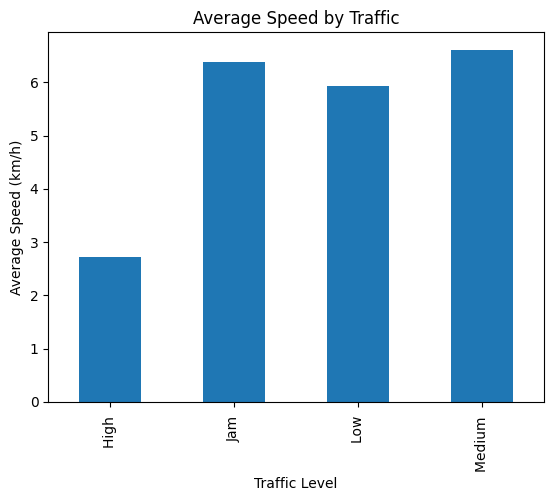

In [89]:
# To calculate the average speed for each traffic condition
avg_speed_by_traffic = df_clean.groupby('Traffic')['Speed_kmph'].mean()

# Visualization
avg_speed_by_traffic.plot(kind='bar')
plt.title('Average Speed by Traffic')
plt.ylabel('Average Speed (km/h)')
plt.xlabel('Traffic Level')
plt.show()


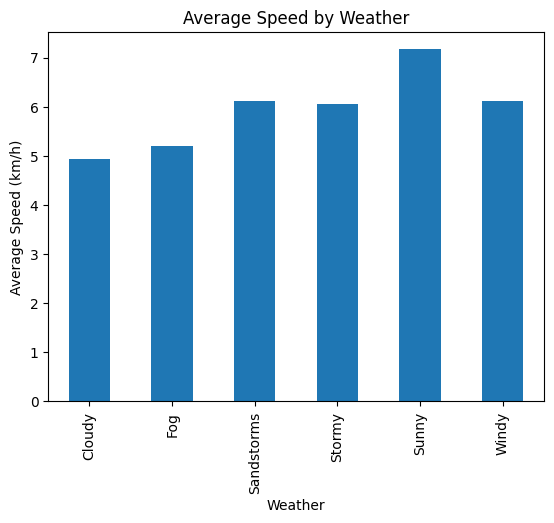

In [90]:
# To calculate the average speed for each weather condition
df_clean.groupby('Weather')['Speed_kmph'].mean().plot(kind='bar')
plt.title('Average Speed by Weather')
plt.ylabel('Average Speed (km/h)')
plt.show()


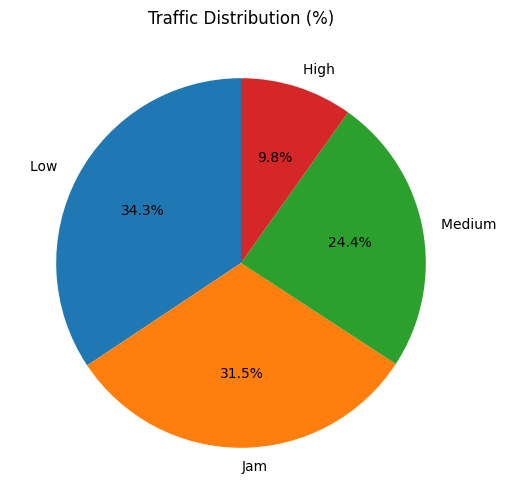

In [91]:
# Calculate percentage distribution of Traffic
traffic_percentage = df_clean['Traffic'].value_counts(normalize=True) * 100

# Pie Chart
plt.figure(figsize=(6,6))
plt.pie(traffic_percentage, labels=traffic_percentage.index, autopct='%1.1f%%',startangle=90)
plt.title('Traffic Distribution (%)')
plt.show()

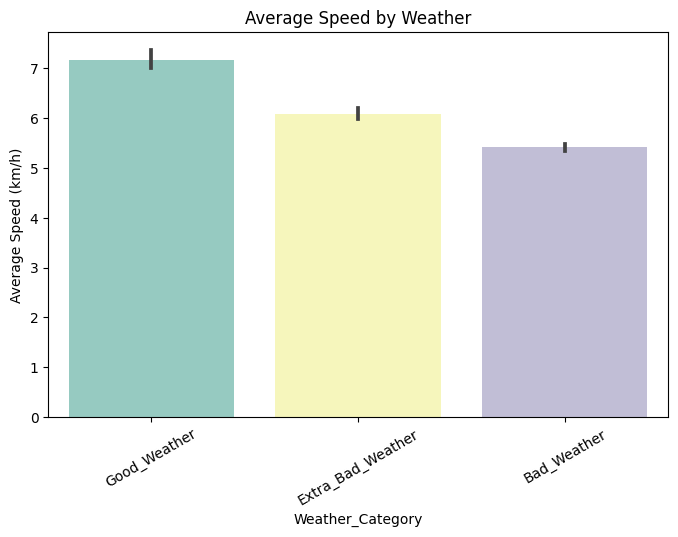

In [92]:
plt.figure(figsize=(8,5))
sns.barplot(x='Weather_Category', y='Speed_kmph', data=df_clean, palette="Set3")
plt.title("Average Speed by Weather")
plt.ylabel("Average Speed (km/h)")
plt.xticks(rotation=30)
plt.show()


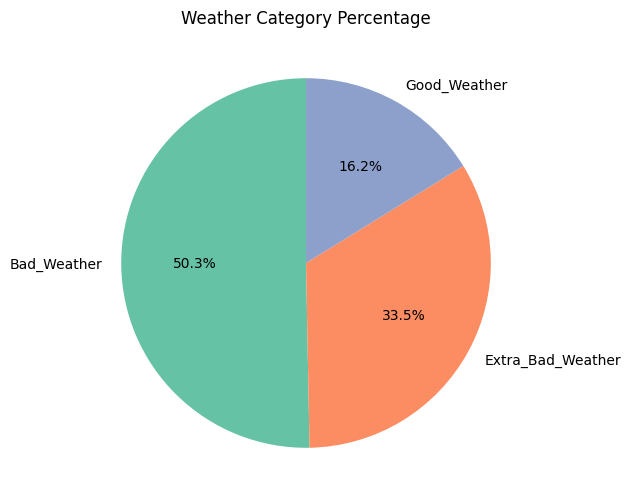

In [93]:
# Pie Chart for Weather Category
plt.figure(figsize=(6,6))
df_clean['Weather_Category'].value_counts().plot.pie(
    autopct="%1.1f%%", 
    colors=sns.color_palette("Set2"), 
    startangle=90
)
plt.title("Weather Category Percentage")
plt.ylabel("")  
plt.show()


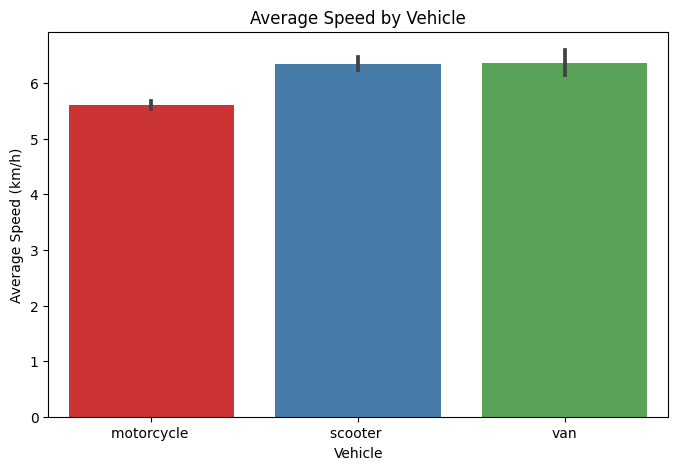

In [94]:
plt.figure(figsize=(8,5))
sns.barplot(x='Vehicle', y='Speed_kmph', data=df_clean,  palette="Set1")
plt.title("Average Speed by Vehicle")
plt.ylabel("Average Speed (km/h)")
plt.show()


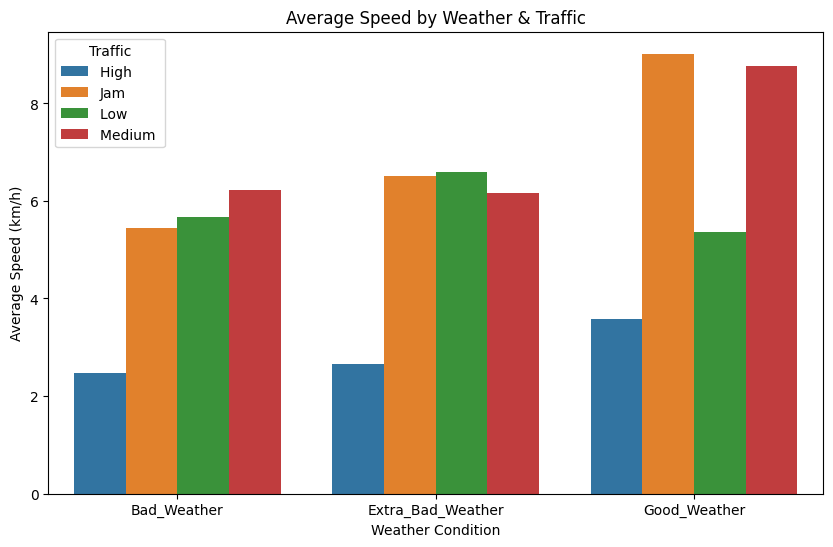

In [95]:
avg_speed_weather_traffic = df_clean.groupby(['Weather_Category','Traffic'])['Speed_kmph'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=avg_speed_weather_traffic, x="Weather_Category", y="Speed_kmph", hue="Traffic")
plt.title("Average Speed by Weather & Traffic")
plt.ylabel("Average Speed (km/h)")
plt.xlabel("Weather Condition")
plt.legend(title="Traffic")
plt.show()

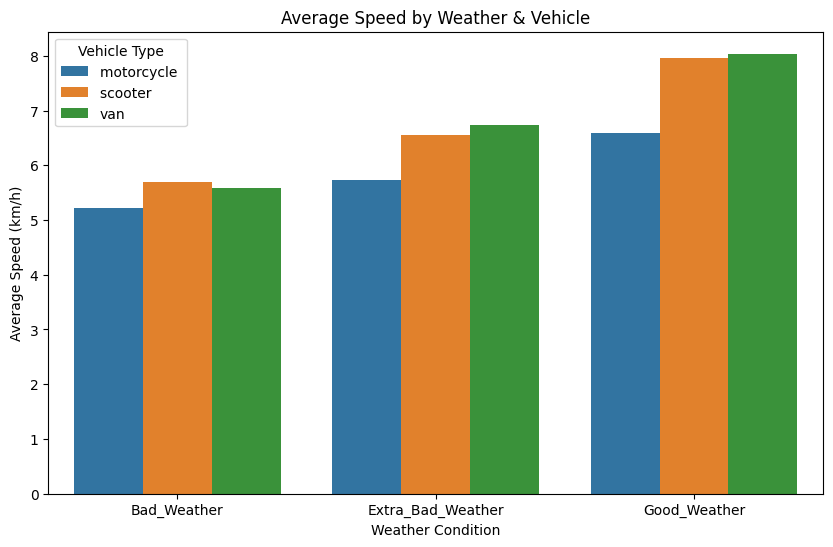

In [96]:
# حساب متوسط السرعة لكل combination من Weather و Vehicle
avg_speed_weather_vehicle = df_clean.groupby(['Weather_Category','Vehicle'])['Speed_kmph'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=avg_speed_weather_vehicle, x="Weather_Category", y="Speed_kmph", hue="Vehicle")
plt.title("Average Speed by Weather & Vehicle")
plt.ylabel("Average Speed (km/h)")
plt.xlabel("Weather Condition")
plt.legend(title="Vehicle Type")
plt.show()

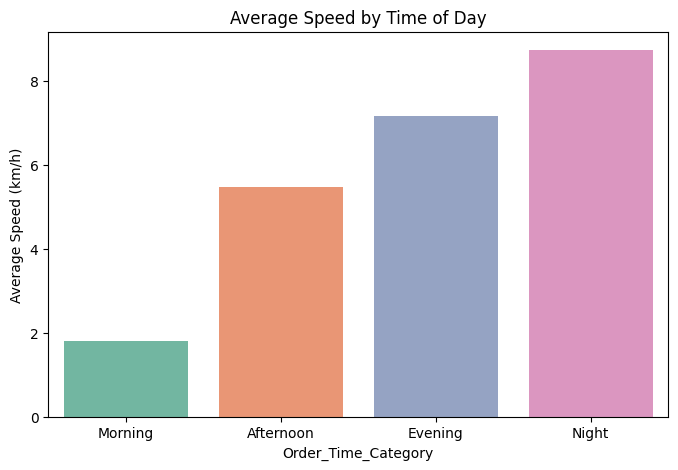

In [97]:
plt.figure(figsize=(8,5))
sns.barplot(x='Order_Time_Category', y='Speed_kmph', data=df_clean, ci=None, palette="Set2",
            order=['Morning','Afternoon','Evening','Night'])
plt.title("Average Speed by Time of Day")
plt.ylabel("Average Speed (km/h)")
plt.show()


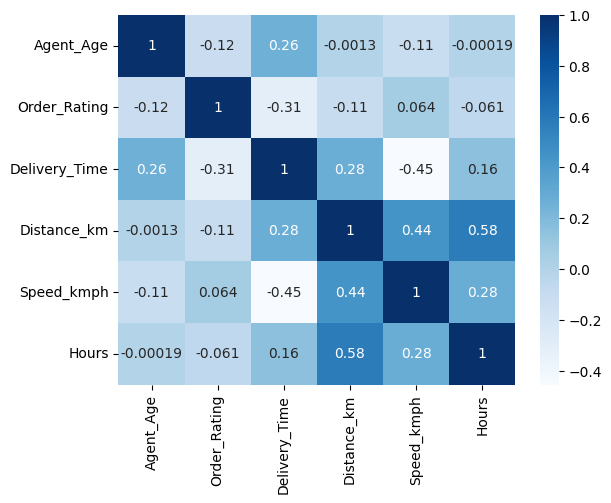

In [98]:
sns.heatmap(df_clean.select_dtypes(include=['number']).corr(), annot=True, cmap="Blues")
plt.show()


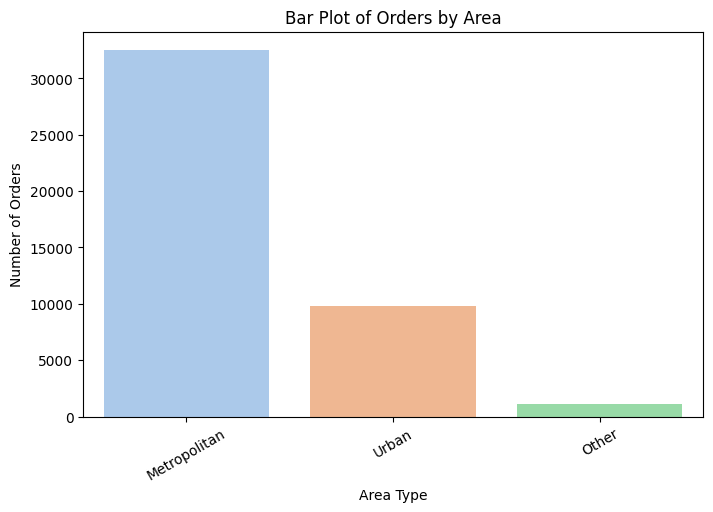

In [100]:
#Visualization of Area

#  Bar Plot 
area_counts = df_clean['Area_Category'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=area_counts.index, y=area_counts.values, palette="pastel")
plt.title("Bar Plot of Orders by Area")
plt.xlabel("Area Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.show()

# How does traffic impact delivery speed?

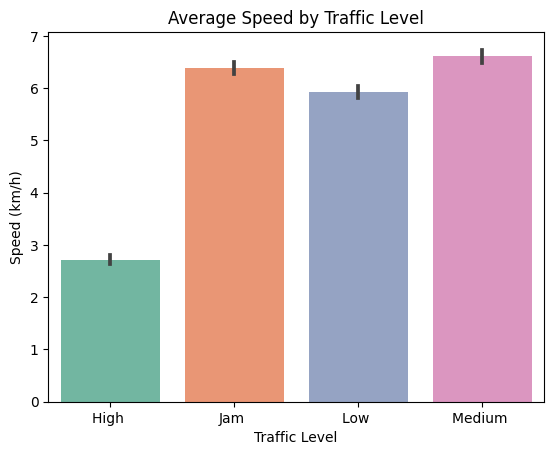

In [101]:
sns.barplot(x="Traffic", y="Speed_kmph", data=df_clean, palette="Set2")
plt.title("Average Speed by Traffic Level")
plt.ylabel("Speed (km/h)")
plt.xlabel("Traffic Level")
plt.show()


# Do area categories affect delivery speed?

Area_Category
Metropolitan    5.762700
Other           6.806485
Urban           6.352286
Name: Speed_kmph, dtype: float64


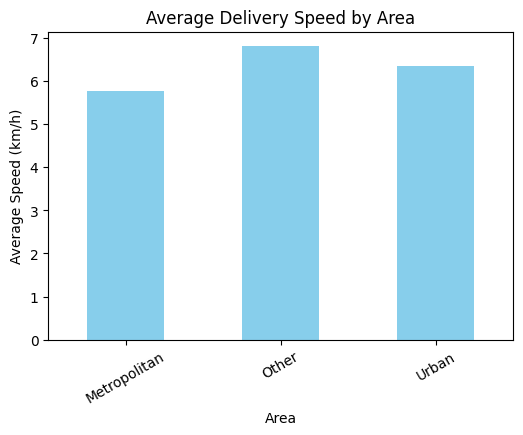

In [102]:
avg_speed_by_area = df_clean.groupby("Area_Category")["Speed_kmph"].mean()
print(avg_speed_by_area)

# Visualization
import matplotlib.pyplot as plt
avg_speed_by_area.plot(kind="bar", color="skyblue", figsize=(6,4))
plt.title("Average Delivery Speed by Area")
plt.ylabel("Average Speed (km/h)")
plt.xlabel("Area")
plt.xticks(rotation=30)
plt.show()


#  How does delivery speed affect customer ratings?

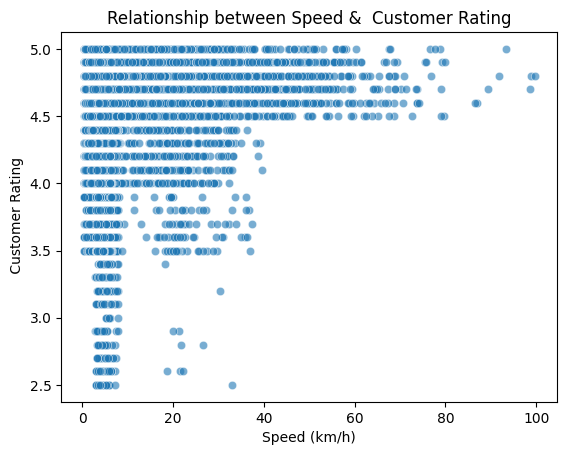

In [103]:
sns.scatterplot(x="Speed_kmph", y="Order_Rating", data=df_clean, alpha=0.6)
plt.title("Relationship between Speed &  Customer Rating")
plt.xlabel("Speed (km/h)")
plt.ylabel(" Customer Rating")
plt.show()


# Which categories of products are delivered faster?

Category
Grocery         23.410503
Skincare         4.882098
Jewelry          4.877800
Outdoors         4.827959
Clothing         4.821464
Home             4.813430
Cosmetics        4.807176
Toys             4.805785
Books            4.798846
Apparel          4.751217
Electronics      4.742903
Shoes            4.739751
Pet Supplies     4.732121
Snacks           4.706729
Sports           4.691198
Kitchen          4.657851
Name: Speed_kmph, dtype: float64


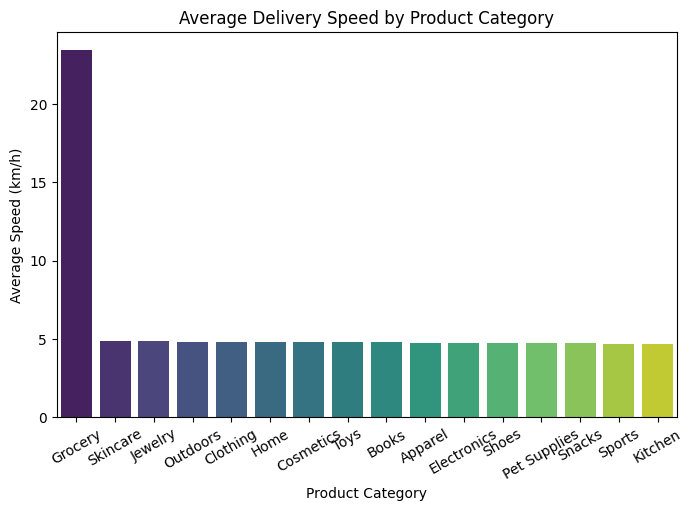

In [104]:
# حساب متوسط السرعة لكل فئة منتج
avg_speed_by_category = df_clean.groupby("Category")["Speed_kmph"].mean().sort_values(ascending=False)

print(avg_speed_by_category)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=avg_speed_by_category.index, y=avg_speed_by_category.values, palette="viridis")
plt.title("Average Delivery Speed by Product Category")
plt.ylabel("Average Speed (km/h)")
plt.xlabel("Product Category")
plt.xticks(rotation=30)
plt.show()


# Do age segments affect delivery speed?

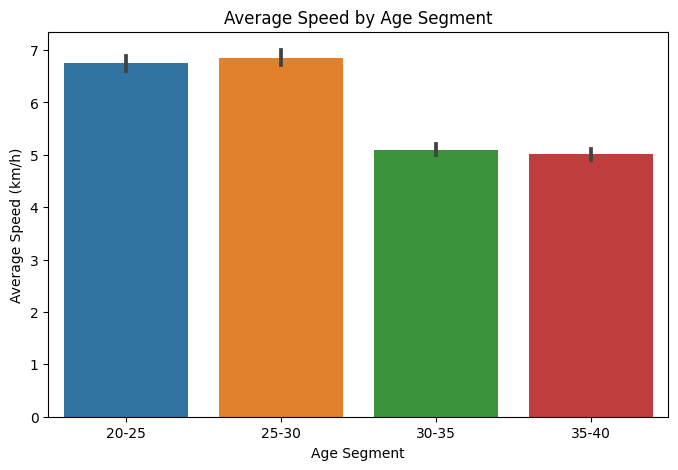

In [107]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x="Age_segment", y="Speed_kmph")
plt.title("Average Speed by Age Segment")
plt.xlabel("Age Segment")
plt.ylabel("Average Speed (km/h)")
plt.show()


# Do different weather conditions affect delivery speed?

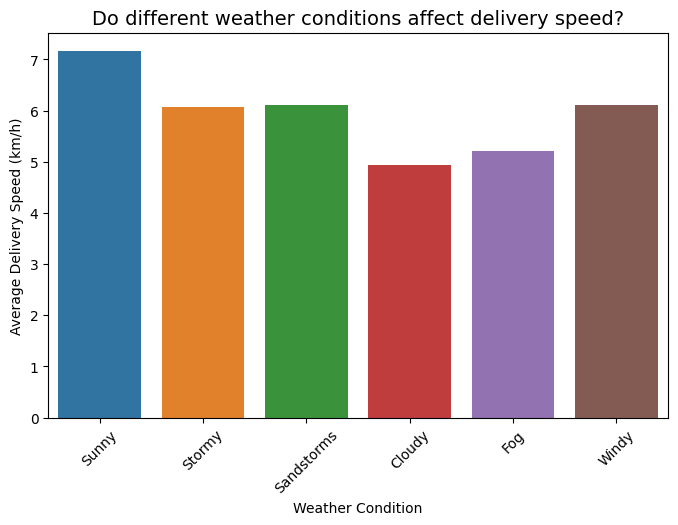

In [109]:
plt.figure(figsize=(8,5))
sns.barplot(x="Weather", y="Speed_kmph", data=df_clean, estimator="mean", errorbar=None)

plt.title("Do different weather conditions affect delivery speed?", fontsize=14)
plt.xlabel("Weather Condition")
plt.ylabel("Average Delivery Speed (km/h)")
plt.xticks(rotation=45)
plt.show()

# Which type of vehicle achieves the highest average delivery speed in each area category?

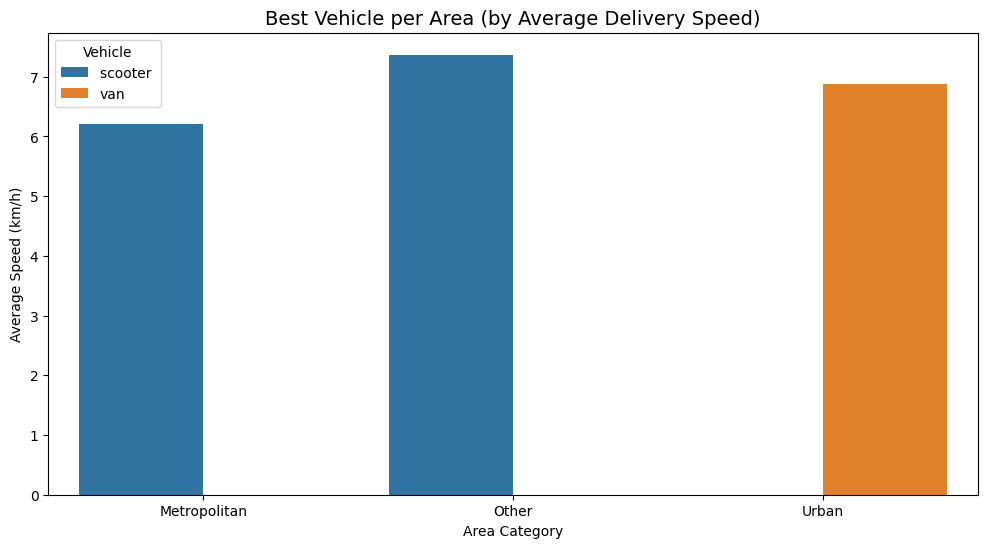

In [114]:
# Group by Area_Category and Vehicle to get mean speed
grouped = df_clean.groupby(['Area_Category', 'Vehicle'])['Speed_kmph'].mean().reset_index()

# Get best vehicle per area (highest average speed)
best_vehicle_per_area = grouped.loc[grouped.groupby('Area_Category')['Speed_kmph'].idxmax()].reset_index(drop=True)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=best_vehicle_per_area, x='Area_Category', y='Speed_kmph', hue='Vehicle')

plt.title("Best Vehicle per Area (by Average Delivery Speed)", fontsize=14)
plt.xlabel("Area Category")
plt.ylabel("Average Speed (km/h)")
plt.show()
